In [19]:
import torch 
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### we'll use a linear regression example to go through the pytorch workflow

In [20]:
# create *known* parameters
weight = 0.7
bias = 0.3

# create data
start = 0
end = 1
step = 0.01

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

len(X), len(y)

(100, 100)

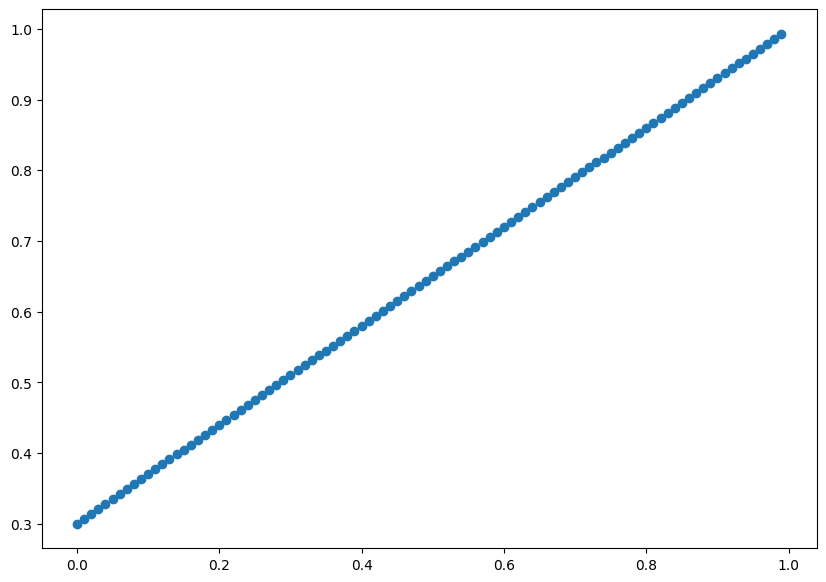

In [21]:
X[:10]

y[:10]

# create a plot
plt.figure(figsize=(10, 7))
plt.scatter(X, y)


In [22]:
### spliting data into training and test sets

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)


(80, 80, 20, 20)

In [23]:
def plot_prediction(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions = None):
    
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
        
        
    
    

In [24]:
from torch import nn

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias
        
        


In [25]:
torch.manual_seed(42)

model_0 = LinearRegression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Inference model

In [27]:
with torch.inference_mode():
    y_preds =  model_0(X_test)
                    
y_preds

tensor([[0.3982],
        [0.4015],
        [0.4049],
        [0.4083],
        [0.4116],
        [0.4150],
        [0.4184],
        [0.4217],
        [0.4251],
        [0.4285],
        [0.4318],
        [0.4352],
        [0.4386],
        [0.4419],
        [0.4453],
        [0.4487],
        [0.4520],
        [0.4554],
        [0.4588],
        [0.4621]])

In [28]:
y_test

tensor([[0.8600],
        [0.8670],
        [0.8740],
        [0.8810],
        [0.8880],
        [0.8950],
        [0.9020],
        [0.9090],
        [0.9160],
        [0.9230],
        [0.9300],
        [0.9370],
        [0.9440],
        [0.9510],
        [0.9580],
        [0.9650],
        [0.9720],
        [0.9790],
        [0.9860],
        [0.9930]])

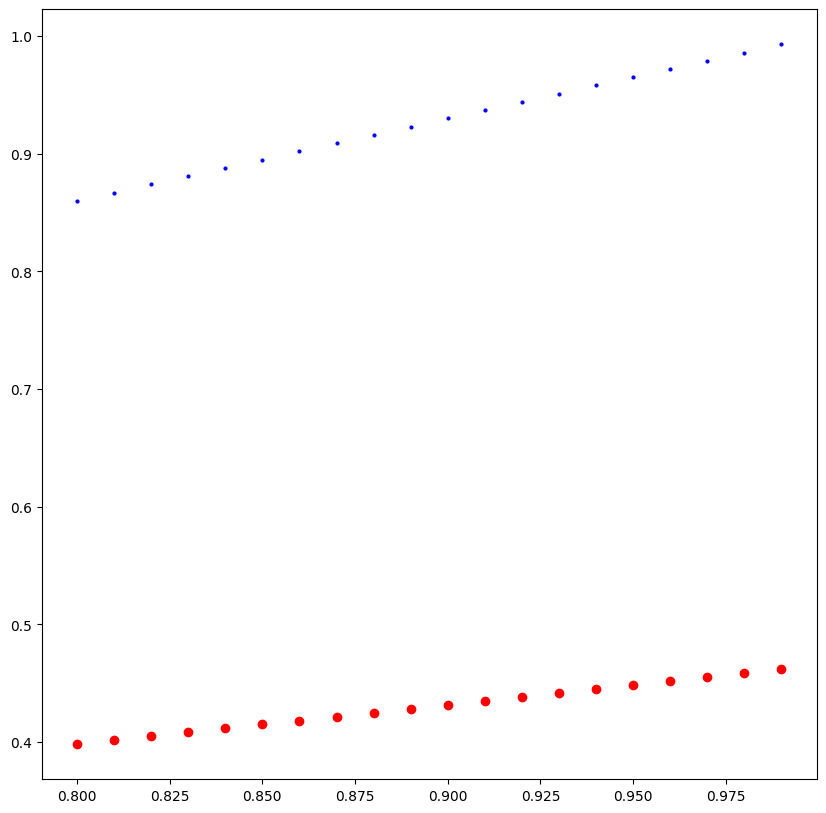

In [29]:
plt.figure(figsize=(10,10))

plt.scatter(X_test, y_test, c="b", s=4, label="Training data")
plt.scatter(X_test, y_preds, c="r")



plt.show()


## Optimizer and loss function 

Things we need to train:

* **Loss function:** A function to measure how poor or how wrong is our model 
* **Optimizer:** Takes into account the loss of a model and adjust the models' parameters

In [30]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [31]:
# setup a loss function 

loss_fn = nn.L1Loss()





# setup an optimizer
optimizet = torch.optim.SGD(params= model_0.parameters(),
                            lr=0.01)

## Training loop (and testing loop) in pytorch

things we need to do:

* Forward pass
* Calculate the loss
* Optimizer zero grad
* Loss backward
* Optimizer step


In [50]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizet.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizet.step()

    print(f"Epoch: {epoch} | Loss: {loss}")

    if epoch % 10 == 0 or epoch == 99:
        model_0.state_dict()
        print(model_0.state_dict())

        
        
        

Epoch: 0 | Loss: 0.03795855492353439
OrderedDict({'weights': tensor([0.5127]), 'bias': tensor([0.3788])})
Epoch: 1 | Loss: 0.037615858018398285
Epoch: 2 | Loss: 0.03727314993739128
Epoch: 3 | Loss: 0.03693045675754547
Epoch: 4 | Loss: 0.03658774867653847
Epoch: 5 | Loss: 0.03624566271901131
Epoch: 6 | Loss: 0.03590331971645355
Epoch: 7 | Loss: 0.035560619086027145
Epoch: 8 | Loss: 0.03521792218089104
Epoch: 9 | Loss: 0.03487522155046463
Epoch: 10 | Loss: 0.034532517194747925
OrderedDict({'weights': tensor([0.5297]), 'bias': tensor([0.3716])})
Epoch: 11 | Loss: 0.03418981283903122
Epoch: 12 | Loss: 0.03384723514318466
Epoch: 13 | Loss: 0.0335053876042366
Epoch: 14 | Loss: 0.033162690699100494
Epoch: 15 | Loss: 0.03281997889280319
Epoch: 16 | Loss: 0.03247728571295738
Epoch: 17 | Loss: 0.03213458135724068
Epoch: 18 | Loss: 0.03179187700152397
Epoch: 19 | Loss: 0.031449176371097565
Epoch: 20 | Loss: 0.03110707364976406
OrderedDict({'weights': tensor([0.5468]), 'bias': tensor([0.3646])})
E

In [52]:
## testing model

model_0.eval()

with torch.inference_mode():
    test_pred = model_0(X_test)

model_0.state_dict()



OrderedDict([('weights', tensor([0.6816])), ('bias', tensor([0.3078]))])

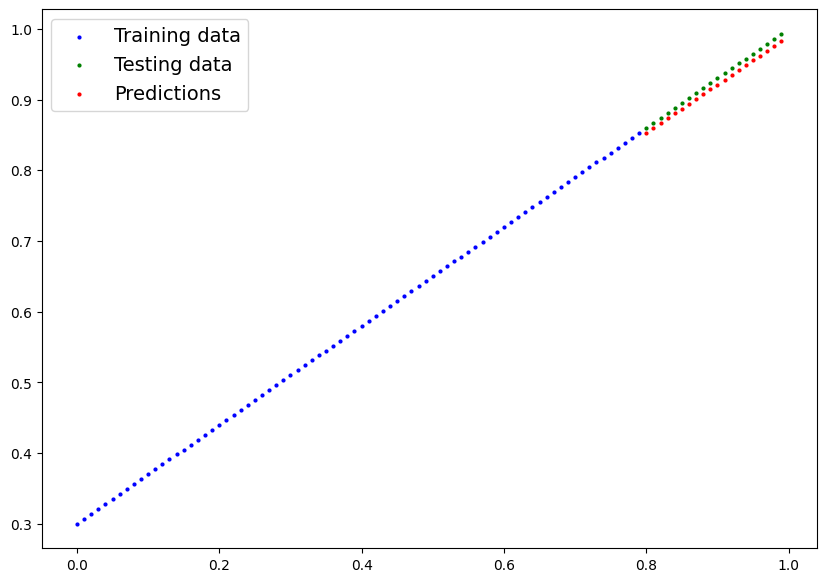

In [53]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, test_pred, c="r", s=4, label="Predictions")
plt.legend(prop={"size": 14});

## Saving a model in pytorch

There are 3 methods:

* torch.save ()
* torch.load()
* torch.nn.Module.load_state_dict()

In [54]:
# initiate the model 
from pathlib import Path

model_folder = Path("models")
model_folder.mkdir(parents=True,
                   exist_ok=True)


PATH = "model.pth"


#save the model's state_dict
torch.save(model_0.state_dict(), model_folder/PATH)



# Load the model 
loaded_model = LinearRegression()

loaded_model.load_state_dict(torch.load(f=model_folder/PATH))

<All keys matched successfully>

In [55]:
 ## make predictions with our loaded model

loaded_model.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)
    print(loaded_model_preds) 



tensor([[0.8531],
        [0.8599],
        [0.8667],
        [0.8735],
        [0.8803],
        [0.8872],
        [0.8940],
        [0.9008],
        [0.9076],
        [0.9144],
        [0.9212],
        [0.9281],
        [0.9349],
        [0.9417],
        [0.9485],
        [0.9553],
        [0.9621],
        [0.9690],
        [0.9758],
        [0.9826]])


In [56]:
print(y_test)

tensor([[0.8600],
        [0.8670],
        [0.8740],
        [0.8810],
        [0.8880],
        [0.8950],
        [0.9020],
        [0.9090],
        [0.9160],
        [0.9230],
        [0.9300],
        [0.9370],
        [0.9440],
        [0.9510],
        [0.9580],
        [0.9650],
        [0.9720],
        [0.9790],
        [0.9860],
        [0.9930]])
